<a href="https://colab.research.google.com/github/b-nadine07/ADD-chemspace-denovo/blob/main/chemical_space_visualization_COLAB_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chemical space visualization — Glucocorticoid receptor (CHEMBL2034)

Practical activity 1 — comparison of the chemical space covered by `DrugEx_GT_epsilon_0.6`
and `GB_GA_mut_r_0.5` (dissimilarity split, sets 0–4) against GR reference chemistry.

**Built for Google Colab.** Run the cells in order (`Runtime ▸ Run all` also works).
Upload `data.zip` when the upload cell asks for it.

## Step 1 — Install packages

Takes ~1 minute. Restarting the runtime afterwards is *not* needed.

In [1]:
!pip -q install rdkit chembl_webresource_client
print("installation finished")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.7 MB/s eta 0:00:00
installation finished


In [2]:
import os, glob, zipfile, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

RDLogger.DisableLog("rdApp.*")     # silence RDKit parsing warnings

RANDOM_STATE = 42

# Molecules sampled per generator for the projections.
# The t-SNE step builds an N x N matrix, so this controls memory:
#   2500 per generator -> ~7000 x 7000 -> ~0.2 GB   (safe on free Colab)
#   5000 per generator -> ~11000 x 11000 -> ~0.5 GB (needs a high-RAM runtime)
N_SAMPLE = 2500

print("python  :", sys.version.split()[0])
print("rdkit   :", Chem.rdBase.rdkitVersion)
print("pandas  :", pd.__version__)

python  : 3.12.13
rdkit   : 2026.03.5
pandas  : 2.2.3


## Step 2 — Upload and unpack `data.zip`

Run the cell and choose `data.zip` in the file picker. If the file is already in the Colab
session (visible in the folder icon on the left), the upload is skipped automatically.

In [3]:
if not os.path.exists("data.zip"):
    from google.colab import files
    uploaded = files.upload()          # choose data.zip in the picker
else:
    print("data.zip already present - skipping upload")

with zipfile.ZipFile("data.zip", "r") as zip_ref:
    zip_ref.extractall("zenodo_data")

print("extracted")

Saving data.zip to data.zip
extracted


## Step 3 — Locate the generator files

The folder layout inside the archive can vary, so the directories are found by **searching
recursively** for the generator names rather than assuming a fixed path. This is the cell that
most often breaks a hardcoded notebook.

In [4]:
GENERATORS = ["DrugEx_GT_epsilon_0.6", "GB_GA_mut_r_0.5"]

def find_generator_files(generator_name, root="zenodo_data"):
    """Recursively find the 5 dissimilarity-split files for one generator."""
    hits = [p for p in glob.glob(f"{root}/**/*.csv", recursive=True)
            if generator_name in p and "_dis_" in os.path.basename(p)
            and "one_column" in os.path.basename(p)]
    return sorted(hits)

file_map = {g: find_generator_files(g) for g in GENERATORS}

for g, paths in file_map.items():
    print(f"{g}: {len(paths)} files")
    for p in paths:
        print("   ", p)
    if len(paths) == 0:
        print("    !! nothing found - listing every csv in the archive:")
        for p in glob.glob("zenodo_data/**/*.csv", recursive=True)[:20]:
            print("      ", p)

DrugEx_GT_epsilon_0.6: 5 files
    zenodo_data/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_0_one_column.csv
    zenodo_data/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_1_one_column.csv
    zenodo_data/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_2_one_column.csv
    zenodo_data/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_3_one_column.csv
    zenodo_data/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_4_one_column.csv
GB_GA_mut_r_0.5: 5 files
    zenodo_data/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_0_one_column.csv
    zenodo_data/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_1_one_column.csv
    zenodo_data/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_2_one_column.csv
    zenodo_data/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_3_one_column.csv
    zenodo_data/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_4_one_column.csv


## Step 4 — Load the generated sets

Headerless files, one SMILES per line. The replicate index (0–4) is parsed from the file name.

In [5]:
def load_generator(generator_name):
    frames = []
    for path in file_map[generator_name]:
        temp = pd.read_csv(path, header=None, names=["SMILES"])
        temp["Generator"] = generator_name
        temp["Replicate"] = os.path.basename(path).split("_dis_")[1].split("_")[0]
        frames.append(temp)
    return pd.concat(frames, ignore_index=True)

drugex_raw = load_generator("DrugEx_GT_epsilon_0.6")
gbga_raw   = load_generator("GB_GA_mut_r_0.5")

print("DrugEx:", drugex_raw.shape)
print("GB_GA :", gbga_raw.shape)
drugex_raw.head()

DrugEx: (50000, 3)
GB_GA : (50000, 3)


,SMILES,Generator,Replicate
0,CNC1(C2CC(O)CC(=O)O2)CC2(C)C(CCC2(O)C#CCc2cccc...,DrugEx_GT_epsilon_0.6,0
1,CC(NC(CC=C1C=C(OCc2ccc(F)cc2)ON1)C(N)=O)OC(NC1...,DrugEx_GT_epsilon_0.6,0
2,CCNC(c1ccc(OC)cc1)C(O)(Cc1ccc(NC(N)c2cc(C=O)co...,DrugEx_GT_epsilon_0.6,0
3,Cc1ncccc1C(=O)N(CCOC1=CC=Cc2cnn(-c3cccc(Cl)c3)...,DrugEx_GT_epsilon_0.6,0
4,Cc1cc(NS(C)(=O)=O)ccc1-n1ncc2c(NCC(C)NS(=O)(=O...,DrugEx_GT_epsilon_0.6,0


## Step 5 — Reference chemistry from ChEMBL (CHEMBL2034)

**Documented choice.** Activities are restricted to the types listed in `TYPES` with
`pchembl_value >= 7` (potency ≥ 100 nM) and an exact relation (`=`), so censored values such as
`>10000 nM` are excluded. The reference set therefore represents *active* GR chemistry.

Much of the CHEMBL2034 data is binding data (`Ki`, `Kd`); `TYPES = ["IC50", "Ki"]` widens the
reference set. Every conclusion depends on this definition, so state it in the report.

The download takes 1–3 minutes.

In [6]:
from chembl_webresource_client.new_client import new_client

TYPES = ["IC50"]          # e.g. ["IC50", "Ki"] to include binding data
PCHEMBL_MIN = 7

activity = new_client.activity
query = activity.filter(
    target_chembl_id="CHEMBL2034",
    standard_type__in=TYPES,
    standard_relation="=",
    pchembl_value__gte=PCHEMBL_MIN,
).only("molecule_chembl_id", "canonical_smiles", "pchembl_value",
       "standard_type", "standard_value", "standard_units")

gr_df = pd.DataFrame(list(query))          # list() forces the download here
gr_df = gr_df.rename(columns={"canonical_smiles": "SMILES"})
gr_df["Generator"] = "ChEMBL reference"

print("activity records retrieved:", len(gr_df))
gr_df.head()

activity records retrieved: 2148


,SMILES,molecule_chembl_id,pchembl_value,standard_type,standard_units,standard_value,type,units,value,Generator
0,CC1=CC(C)(C)Nc2ccc3c(c21)/C(=C/c1ccsc1)Oc1ccc(...,CHEMBL134277,7.00,IC50,nM,100.0,IC50,nM,100.0,ChEMBL reference
1,CCc1ccccc1/C=C1\Oc2ccc(F)cc2-c2ccc3c(c21)C(C)=...,CHEMBL415524,7.11,IC50,nM,77.0,IC50,nM,77.0,ChEMBL reference
2,CC(=O)O[C@]1(C(C)=O)CC[C@H]2[C@@H]3C[C@H](C)C4...,CHEMBL717,8.00,IC50,nM,10.0,IC50,nM,10.0,ChEMBL reference
3,COc1ccccc1/C=C1\Oc2ccc(F)cc2-c2ccc3c(c21)C(C)=...,CHEMBL335996,7.05,IC50,nM,90.0,IC50,nM,90.0,ChEMBL reference
4,CN(C)c1ccc([C@H]2C[C@]3(C)[C@@H](CC[C@]3(O)CCC...,CHEMBL1908373,7.57,IC50,nM,27.0,IC50,nM,27.0,ChEMBL reference


## Step 6 — Curation

Identical treatment for all three datasets so they stay comparable:

1. `Chem.MolFromSmiles` returns `None` for unparsable SMILES → this is the **validity** rate.
   It sanitizes by default, so a separate `SanitizeMol` call is unnecessary.
2. **Largest fragment** — strips salts/counter-ions (`.Cl`, `.[Na+]`). Otherwise a
   hydrochloride counts as a different compound from its free base and its MW is inflated.
   ChEMBL entries are often salts.
3. **Canonical SMILES** — `c1ccccc1C(=O)O` and `OC(=O)c1ccccc1` are the same molecule written
   two ways; de-duplicating on the raw string misses those.
4. **De-duplicate within each dataset only** — overlap *between* a generator and the reference
   is a result to measure, not something to remove.

Only canonical SMILES are stored (not RDKit `Mol` objects): 100 000 `Mol` objects would use
several GB of RAM, and molecules are cheap to rebuild on demand.

In [7]:
chooser = rdMolStandardize.LargestFragmentChooser()

def curate(df, name):
    canon = []
    for smi in df["SMILES"]:
        m = Chem.MolFromSmiles(smi)
        if m is not None and "." in smi:
            m = chooser.choose(m)
        if m is not None and m.GetNumHeavyAtoms() < 3:
            m = None
        canon.append(Chem.MolToSmiles(m) if m is not None else None)

    out = df.copy()
    out["CanonicalSMILES"] = canon

    valid = out.dropna(subset=["CanonicalSMILES"])
    clean = valid.drop_duplicates(subset=["CanonicalSMILES"]).reset_index(drop=True)

    stats = dict(dataset=name, n_raw=len(out), n_valid=len(valid),
                 validity=round(len(valid) / len(out), 4),
                 n_unique=len(clean),
                 uniqueness=round(len(clean) / max(len(valid), 1), 4))
    return clean, stats

reference_clean, s_ref = curate(gr_df, "ChEMBL reference")
drugex_clean,    s_dx  = curate(drugex_raw, "DrugEx")
gbga_clean,      s_gb  = curate(gbga_raw, "GB_GA")

curation_stats = pd.DataFrame([s_ref, s_dx, s_gb])
curation_stats

,dataset,n_raw,n_valid,validity,n_unique,uniqueness
0,ChEMBL reference,2148,2148,1.0,1282,0.5968
1,DrugEx,50000,50000,1.0,49976,0.9995
2,GB_GA,50000,50000,1.0,49913,0.9983


In [8]:
# keep the exact reference chemistry the report refers to
reference_clean[["molecule_chembl_id", "CanonicalSMILES", "pchembl_value"]] \
    .to_csv("reference_CHEMBL2034_curated.csv", index=False)
print("saved reference_CHEMBL2034_curated.csv -", len(reference_clean), "molecules")

saved reference_CHEMBL2034_curated.csv - 1282 molecules


## Step 7 — Combined table for the projections

Each generator is sub-sampled to `N_SAMPLE`; the whole reference set is kept, so ~50 000
generated points do not bury it. The **quantitative** statistics later use the full sets.

In [9]:
drugex_sample = drugex_clean.sample(n=min(N_SAMPLE, len(drugex_clean)),
                                    random_state=RANDOM_STATE).copy()
gbga_sample   = gbga_clean.sample(n=min(N_SAMPLE, len(gbga_clean)),
                                  random_state=RANDOM_STATE).copy()
reference_sample = reference_clean.copy()

drugex_sample["Origin"] = "DrugEx"
gbga_sample["Origin"] = "GB_GA"
reference_sample["Origin"] = "ChEMBL reference"

chemspace_df = pd.concat(
    [reference_sample, drugex_sample, gbga_sample], ignore_index=True
)[["CanonicalSMILES", "Origin"]]

print(chemspace_df["Origin"].value_counts())

Origin
DrugEx              2500
GB_GA               2500
ChEMBL reference    1282
Name: count, dtype: int64


## Step 8 — Molecular representations

**Morgan fingerprints** (radius 2, 2048 bits) encode which *substructures* are present:
similarity means shared chemotypes.

**Physicochemical descriptors** encode *bulk properties*: similarity means comparable size,
polarity and flexibility regardless of scaffold.

They answer different questions, which is why both are used.

In [10]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
DESCRIPTOR_NAMES = ["MW", "LogP", "TPSA", "HBD", "HBA", "RotatableBonds"]

def physchem(mol):
    return [Descriptors.MolWt(mol), Crippen.MolLogP(mol), rdMolDescriptors.CalcTPSA(mol),
            Lipinski.NumHDonors(mol), Lipinski.NumHAcceptors(mol),
            Lipinski.NumRotatableBonds(mol)]

def featurise(smiles_list):
    """Build fingerprints and descriptors from SMILES, one molecule at a time."""
    fps = np.zeros((len(smiles_list), 2048), dtype=np.uint8)
    desc = np.zeros((len(smiles_list), len(DESCRIPTOR_NAMES)), dtype=np.float32)
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi)
        arr = np.zeros((2048,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(morgan_generator.GetFingerprint(m), arr)
        fps[i] = arr
        desc[i] = physchem(m)
    return fps, desc

X_fp, X_desc = featurise(chemspace_df["CanonicalSMILES"].tolist())
X_desc_scaled = StandardScaler().fit_transform(X_desc)   # scales differ wildly -> standardise

print("fingerprints:", X_fp.shape, "| descriptors:", X_desc.shape)

fingerprints: (6282, 2048) | descriptors: (6282, 6)


## Step 9 — Plot helper

`plt.show()` clears the figure, so **`savefig` must come before `show()`** — otherwise the
saved PNG is empty. Every plot goes through this helper so the mistake cannot recur.

In [11]:
COLORS = {"ChEMBL reference": "#111111", "DrugEx": "#0072B2", "GB_GA": "#D55E00"}

def scatter_by_origin(df, x, y, title, filename, xlabel=None, ylabel=None):
    plt.figure(figsize=(9, 7))
    for origin in ["DrugEx", "GB_GA", "ChEMBL reference"]:      # reference plotted last = on top
        sub = df[df["Origin"] == origin]
        plt.scatter(sub[x], sub[y], label=origin,
                    s=14 if origin == "ChEMBL reference" else 6,
                    alpha=0.9 if origin == "ChEMBL reference" else 0.35,
                    linewidths=0, c=COLORS[origin])
    plt.xlabel(xlabel or x); plt.ylabel(ylabel or y)
    plt.title(title); plt.legend(markerscale=2); plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")   # BEFORE show()
    plt.show()
    print("saved", filename)

## Step 10 — PCA on Morgan fingerprints

explained variance  PC1 0.056 | PC2 0.037 | total 0.093


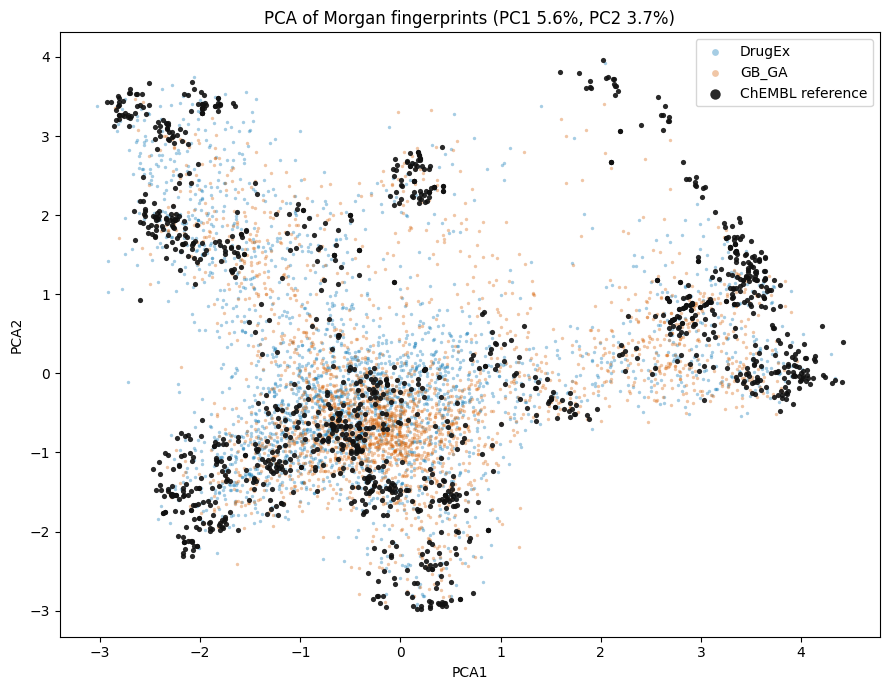

saved PCA_Morgan_GR_chemical_space.png


In [12]:
pca_fp = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca_fp.fit_transform(X_fp)
chemspace_df["PCA1"], chemspace_df["PCA2"] = coords[:, 0], coords[:, 1]

evr = pca_fp.explained_variance_ratio_
print(f"explained variance  PC1 {evr[0]:.3f} | PC2 {evr[1]:.3f} | total {evr[:2].sum():.3f}")

scatter_by_origin(chemspace_df, "PCA1", "PCA2",
                  f"PCA of Morgan fingerprints (PC1 {evr[0]*100:.1f}%, PC2 {evr[1]*100:.1f}%)",
                  "PCA_Morgan_GR_chemical_space.png")

## Step 11 — t-SNE on Morgan fingerprints (Tanimoto distance)

Fingerprints are **binary**, and the standard similarity measure for them is Tanimoto, not
Euclidean distance. A pre-computed Tanimoto distance matrix is passed to t-SNE
(`metric="precomputed"`, which requires `init="random"`).

Tanimoto = intersection / union of set bits, computed for all pairs at once with a matrix
product rather than a Python loop. **This is the slowest cell — 2–5 minutes.**

distance matrix (6282, 6282) (158 MB)


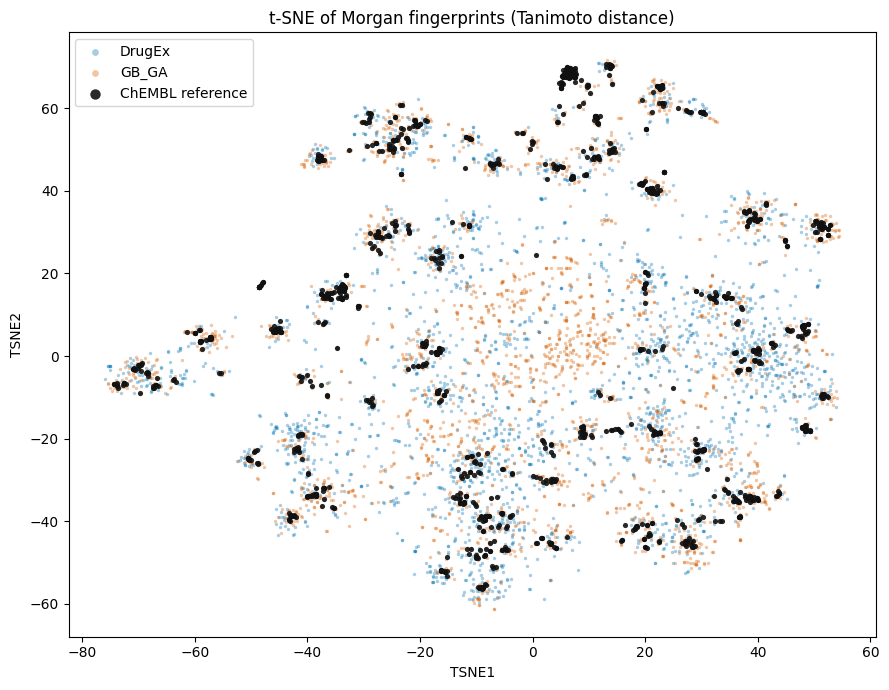

saved tSNE_Morgan_GR_chemical_space.png


In [13]:
def tanimoto_distance_matrix(X):
    X = X.astype(np.float32)
    intersection = X @ X.T
    counts = X.sum(axis=1)
    union = counts[:, None] + counts[None, :] - intersection
    D = (1.0 - intersection / union).astype(np.float32)
    np.fill_diagonal(D, 0.0)
    return D

D_tanimoto = tanimoto_distance_matrix(X_fp)
print(f"distance matrix {D_tanimoto.shape} ({D_tanimoto.nbytes/1e6:.0f} MB)")

tsne_fp = TSNE(n_components=2, metric="precomputed", init="random",
               perplexity=30, learning_rate="auto", random_state=RANDOM_STATE)
coords = tsne_fp.fit_transform(D_tanimoto)
chemspace_df["TSNE1"], chemspace_df["TSNE2"] = coords[:, 0], coords[:, 1]

del D_tanimoto            # free ~0.2 GB before the next steps
import gc; gc.collect()

scatter_by_origin(chemspace_df, "TSNE1", "TSNE2",
                  "t-SNE of Morgan fingerprints (Tanimoto distance)",
                  "tSNE_Morgan_GR_chemical_space.png")

## Step 12 — PCA on physicochemical descriptors

explained variance  PC1 0.573 | PC2 0.222 | total 0.795


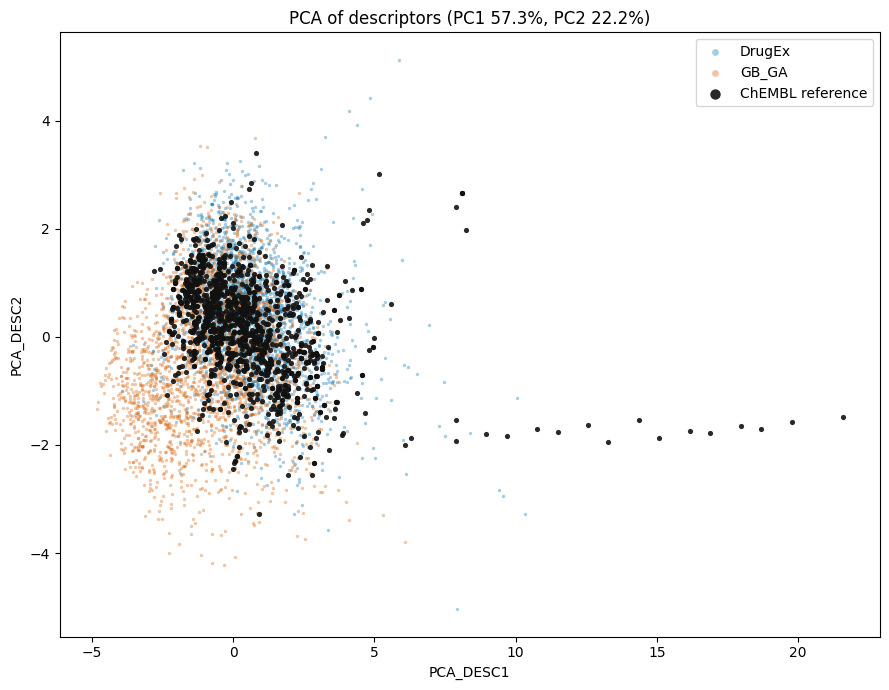

saved PCA_descriptors_GR_chemical_space.png


,PC1,PC2
MW,0.473,0.353
LogP,0.124,0.816
TPSA,0.494,-0.283
HBD,0.383,-0.275
HBA,0.460,-0.179
RotatableBonds,0.398,0.149


In [14]:
pca_desc = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca_desc.fit_transform(X_desc_scaled)
chemspace_df["PCA_DESC1"], chemspace_df["PCA_DESC2"] = coords[:, 0], coords[:, 1]

evr_d = pca_desc.explained_variance_ratio_
print(f"explained variance  PC1 {evr_d[0]:.3f} | PC2 {evr_d[1]:.3f} | total {evr_d[:2].sum():.3f}")

scatter_by_origin(chemspace_df, "PCA_DESC1", "PCA_DESC2",
                  f"PCA of descriptors (PC1 {evr_d[0]*100:.1f}%, PC2 {evr_d[1]*100:.1f}%)",
                  "PCA_descriptors_GR_chemical_space.png")

pd.DataFrame(pca_desc.components_.T, index=DESCRIPTOR_NAMES,
             columns=["PC1", "PC2"]).round(3)

## Step 13 — t-SNE on physicochemical descriptors

Same representation, second projection method. Euclidean distance is correct here: the descriptors are continuous and standardised.

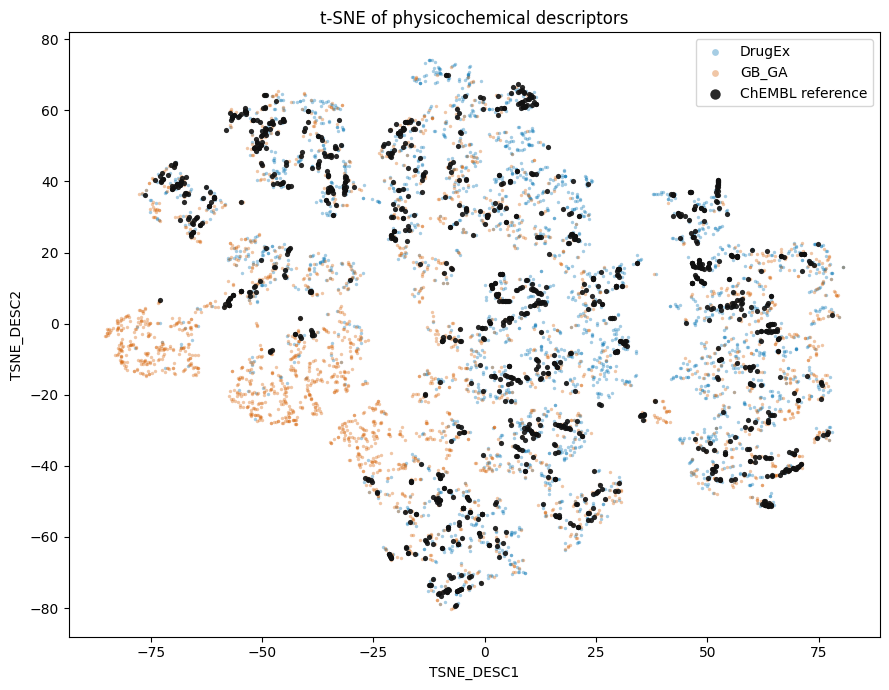

saved tSNE_descriptors_GR_chemical_space.png


In [15]:
tsne_desc = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                 init="pca", random_state=RANDOM_STATE)
coords = tsne_desc.fit_transform(X_desc_scaled)
chemspace_df["TSNE_DESC1"], chemspace_df["TSNE_DESC2"] = coords[:, 0], coords[:, 1]

scatter_by_origin(chemspace_df, "TSNE_DESC1", "TSNE_DESC2",
                  "t-SNE of physicochemical descriptors",
                  "tSNE_descriptors_GR_chemical_space.png")

## Step 14 — Property distributions

The projections show *where* the sets sit; these show *why*.

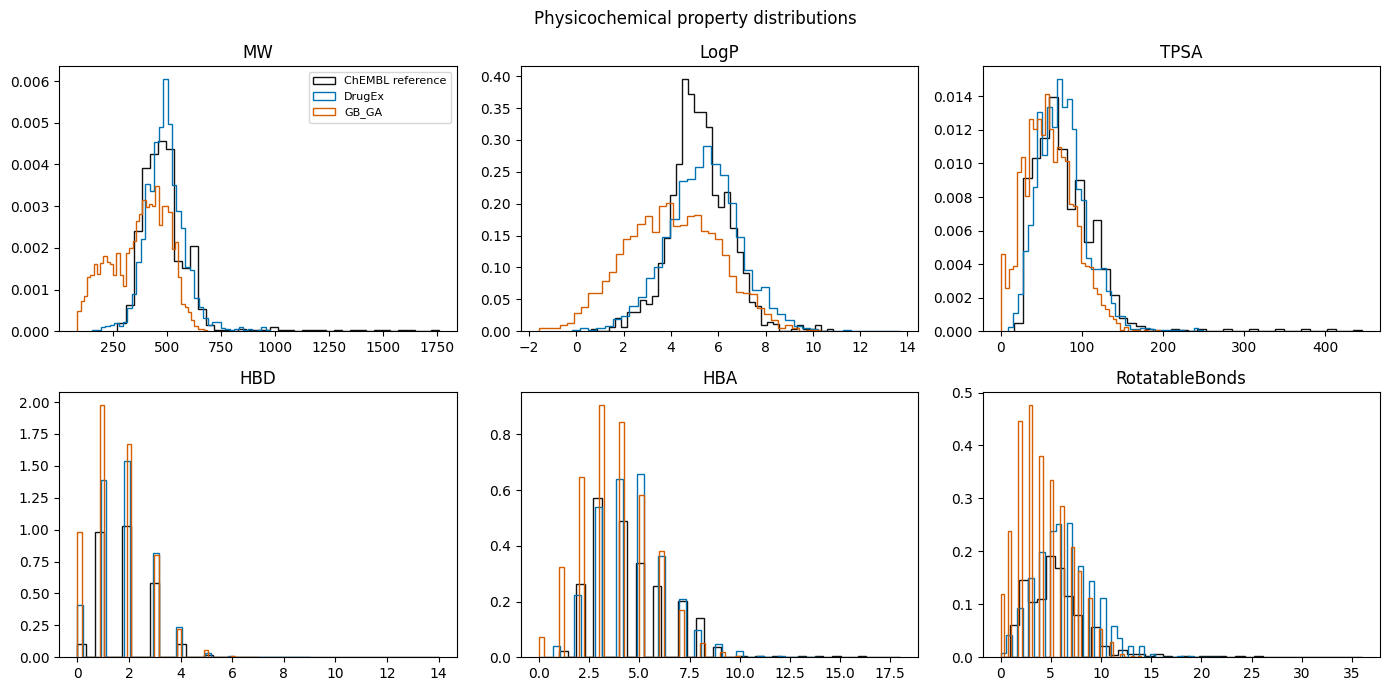

MW              LogP             TPSA             \
                        mean         std  mean   std       mean        std   
Origin                                                                       
ChEMBL reference  490.250000  131.089996  5.20  1.24  79.269997  41.509998   
DrugEx            490.010010   92.320000  5.38  1.54  75.970001  29.830000   
GB_GA             373.149994  129.100006  4.05  1.96  59.900002  30.459999   

                   HBD         HBA       RotatableBonds        
                  mean   std  mean   std           mean   std  
Origin                                                         
ChEMBL reference  1.98  1.34  4.57  2.11           5.57  3.67  
DrugEx            1.84  1.11  4.62  1.79           6.42  2.98  
GB_GA             1.57  1.12  3.68  1.75           4.28  2.58

In [16]:
desc_df = pd.DataFrame(X_desc, columns=DESCRIPTOR_NAMES)
desc_df["Origin"] = chemspace_df["Origin"].values

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, name in zip(axes.ravel(), DESCRIPTOR_NAMES):
    for origin in ["ChEMBL reference", "DrugEx", "GB_GA"]:
        ax.hist(desc_df.loc[desc_df["Origin"] == origin, name], bins=40, density=True,
                histtype="step", lw=1.8, color=COLORS[origin], label=origin)
    ax.set_title(name)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Physicochemical property distributions")
fig.tight_layout()
fig.savefig("property_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

desc_df.groupby("Origin")[DESCRIPTOR_NAMES].agg(["mean", "std"]).round(2)

## Step 15 — Nearest-neighbour similarity to the reference (full sets)

The plots are qualitative; these are the numbers the report should quote. The reference
compared against itself gives the scale: ChEMBL activity sets are congeneric analogue series,
so their internal neighbours are very similar.

Computed in chunks so memory stays flat over 50 000 molecules.

In [17]:
def fingerprints_of(smiles_list, chunk=5000):
    out = np.zeros((len(smiles_list), 2048), dtype=np.uint8)
    for i, smi in enumerate(smiles_list):
        arr = np.zeros((2048,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(
            morgan_generator.GetFingerprint(Chem.MolFromSmiles(smi)), arr)
        out[i] = arr
    return out

def tanimoto_to(A, B):
    inter = A @ B.T
    return inter / (A.sum(1)[:, None] + B.sum(1)[None, :] - inter)

fp_ref = fingerprints_of(reference_clean["CanonicalSMILES"].tolist()).astype(np.float32)

def nn_to_reference(df, chunk=5000):
    fps = fingerprints_of(df["CanonicalSMILES"].tolist()).astype(np.float32)
    best = np.empty(len(fps), dtype=np.float32)
    for s in range(0, len(fps), chunk):
        best[s:s+chunk] = tanimoto_to(fps[s:s+chunk], fp_ref).max(1)
    return best

nn_drugex = nn_to_reference(drugex_clean)
nn_gbga   = nn_to_reference(gbga_clean)

S_ref = tanimoto_to(fp_ref, fp_ref)
np.fill_diagonal(S_ref, -1)                 # exclude the self-match
nn_ref = S_ref.max(1)

pd.DataFrame({
    "median NN Tc to reference": [np.median(nn_ref), np.median(nn_drugex), np.median(nn_gbga)],
    "% above Tc 0.4": [100*(nn_ref > .4).mean(), 100*(nn_drugex > .4).mean(), 100*(nn_gbga > .4).mean()],
    "% above Tc 0.6": [100*(nn_ref > .6).mean(), 100*(nn_drugex > .6).mean(), 100*(nn_gbga > .6).mean()],
}, index=["ChEMBL reference", "DrugEx", "GB_GA"]).round(3)

,median NN Tc to reference,% above Tc 0.4,% above Tc 0.6
ChEMBL reference,0.836,99.532,97.660
DrugEx,0.376,44.824,13.619
GB_GA,0.432,54.815,23.757


In [18]:
# internal diversity = 1 - mean pairwise Tanimoto (2000-molecule sample per set)
rng = np.random.default_rng(RANDOM_STATE)

def internal_diversity(df, n=2000):
    fps = fingerprints_of(df["CanonicalSMILES"].tolist()).astype(np.float32)
    idx = rng.choice(len(fps), min(n, len(fps)), replace=False)
    M = tanimoto_to(fps[idx], fps[idx])
    iu = np.triu_indices_from(M, k=1)
    return 1 - M[iu].mean()

pd.Series({
    "ChEMBL reference": internal_diversity(reference_clean),
    "DrugEx": internal_diversity(drugex_clean),
    "GB_GA": internal_diversity(gbga_clean),
}, name="internal diversity").round(3)

,internal diversity
ChEMBL reference,0.857
DrugEx,0.873
GB_GA,0.901


## Step 16 — Bemis–Murcko scaffolds

Whether a generator reuses known chemotypes or invents new ones — a substructure view the projections cannot give directly.

In [19]:
def murcko(df):
    scaf = []
    for smi in df["CanonicalSMILES"]:
        try:
            scaf.append(Chem.MolToSmiles(
                MurckoScaffold.GetScaffoldForMol(Chem.MolFromSmiles(smi))))
        except Exception:
            scaf.append(None)
    return pd.Series(scaf)

scaf_ref, scaf_dx, scaf_gb = murcko(reference_clean), murcko(drugex_clean), murcko(gbga_clean)
ref_scaffolds = set(scaf_ref.dropna())

def scaffold_stats(scaf, name):
    s = scaf.dropna()
    return dict(dataset=name, n_molecules=len(s), n_scaffolds=s.nunique(),
                scaffolds_per_molecule=round(s.nunique()/len(s), 3),
                pct_on_reference_scaffold=round(100*s.isin(ref_scaffolds).mean(), 2),
                pct_reference_scaffolds_recovered=round(
                    100*len(ref_scaffolds & set(s))/len(ref_scaffolds), 2))

display(pd.DataFrame([scaffold_stats(scaf_ref, "ChEMBL reference"),
                      scaffold_stats(scaf_dx, "DrugEx"),
                      scaffold_stats(scaf_gb, "GB_GA")]))

ref_set = set(reference_clean["CanonicalSMILES"])
print("DrugEx molecules identical to a reference ligand:",
      drugex_clean["CanonicalSMILES"].isin(ref_set).sum())
print("GB_GA  molecules identical to a reference ligand:",
      gbga_clean["CanonicalSMILES"].isin(ref_set).sum())

,dataset,n_molecules,n_scaffolds,scaffolds_per_molecule,pct_on_reference_scaffold,pct_reference_scaffolds_recovered
0,ChEMBL reference,1282,483,0.377,100.00,100.00
1,DrugEx,49976,39307,0.787,5.07,28.36
2,GB_GA,49913,21405,0.429,17.96,75.16


DrugEx molecules identical to a reference ligand: 16
GB_GA  molecules identical to a reference ligand: 22


## Step 17 — Outliers

## Step 17 — Outliers

Two different notions of "outlier", reported separately because they measure different things:

1. **Chemical-space outliers** — the molecules with the *lowest nearest-neighbour Tanimoto to
   the reference*. This is what "outlier in chemical space" means and is the primary analysis.
2. **Property outliers** — extremes of molecular weight. These reveal degenerate generator
   output (fragments, oversized conjugates) rather than novelty.

**Size control matters.** Tanimoto on Morgan fingerprints is size-biased: small molecules set
few bits, so they score low against everything. Without a size window the lowest-Tc list is
dominated by tiny fragments and hides genuinely novel drug-sized chemotypes. The correlation
printed below shows how strong that bias is for each generator.

In [21]:
MW_MIN, MW_MAX = 250, 600      # size window for the chemical-space outliers

outlier_tables = {}
for name, df, nn in [("DrugEx", drugex_clean, nn_drugex), ("GB_GA", gbga_clean, nn_gbga)]:
    d = df.copy()
    d["NN_Tc"] = nn                                    # reuse step 15, no recomputation
    d["MW"] = [Descriptors.MolWt(Chem.MolFromSmiles(s)) for s in d["CanonicalSMILES"]]
    outlier_tables[name] = d

    in_window = d[(d["MW"] >= MW_MIN) & (d["MW"] <= MW_MAX)]
    print(f"--- {name} ---")
    print(f"  corr(NN_Tc, MW) = {d[['NN_Tc','MW']].corr().iloc[0,1]:.3f}")
    print(f"  200 lowest-Tc, no size control : median MW {d.nsmallest(200,'NN_Tc')['MW'].median():.0f}")
    print(f"  200 lowest-Tc, MW {MW_MIN}-{MW_MAX}   : median MW {in_window.nsmallest(200,'NN_Tc')['MW'].median():.0f}")
    print(f"  MW p1/p50/p99 = {np.percentile(d['MW'],[1,50,99]).round(0)}")

--- DrugEx ---
  corr(NN_Tc, MW) = 0.108
  200 lowest-Tc, no size control : median MW 454
  200 lowest-Tc, MW 250-600   : median MW 459
  MW p1/p50/p99 = [270. 485. 785.]
--- GB_GA ---
  corr(NN_Tc, MW) = 0.700
  200 lowest-Tc, no size control : median MW 120
  200 lowest-Tc, MW 250-600   : median MW 276
  MW p1/p50/p99 = [109. 393. 605.]


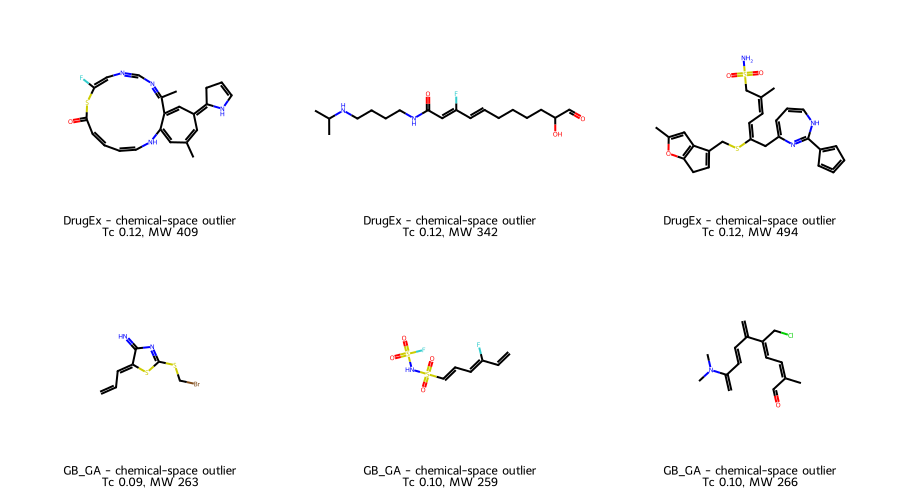

In [22]:
# primary: chemical-space outliers (lowest Tanimoto to reference, size-controlled)
picks, legends = [], []
for name in ["DrugEx", "GB_GA"]:
    d = outlier_tables[name]
    sel = d[(d["MW"] >= MW_MIN) & (d["MW"] <= MW_MAX)].nsmallest(3, "NN_Tc")
    for _, r in sel.iterrows():
        picks.append(Chem.MolFromSmiles(r["CanonicalSMILES"]))
        legends.append(f"{name} - chemical-space outlier\nTc {r['NN_Tc']:.2f}, MW {r['MW']:.0f}")

Draw.MolsToGridImage(picks, molsPerRow=3, subImgSize=(300, 250), legends=legends)

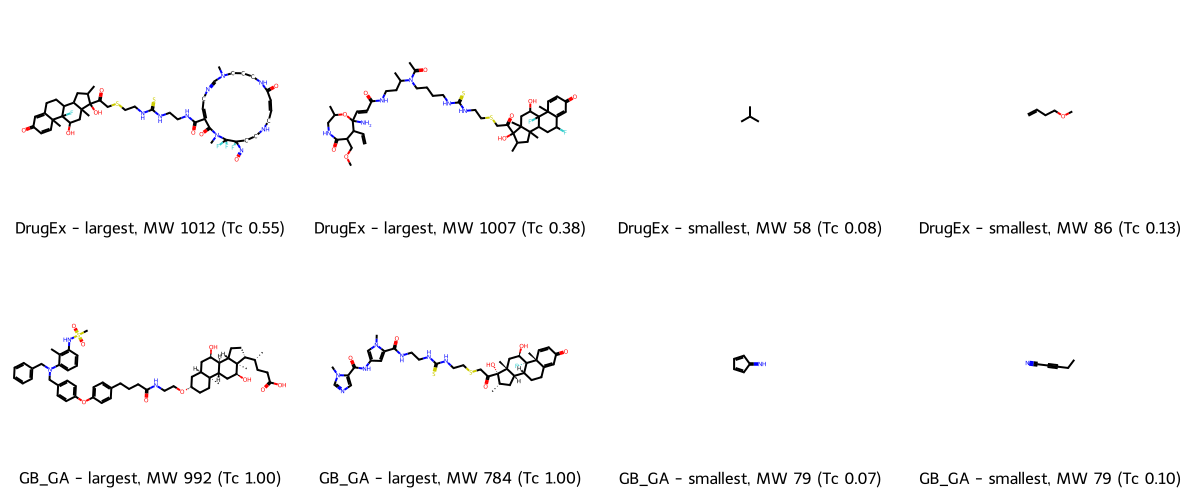

In [23]:
# secondary: property outliers (MW extremes) - degenerate output, not novelty
picks, legends = [], []
for name in ["DrugEx", "GB_GA"]:
    d = outlier_tables[name]
    for _, r in d.nlargest(2, "MW").iterrows():
        picks.append(Chem.MolFromSmiles(r["CanonicalSMILES"]))
        legends.append(f"{name} - largest, MW {r['MW']:.0f} (Tc {r['NN_Tc']:.2f})")
    for _, r in d.nsmallest(2, "MW").iterrows():
        picks.append(Chem.MolFromSmiles(r["CanonicalSMILES"]))
        legends.append(f"{name} - smallest, MW {r['MW']:.0f} (Tc {r['NN_Tc']:.2f})")

Draw.MolsToGridImage(picks, molsPerRow=4, subImgSize=(300, 250), legends=legends)

## Step 18 — Download the results

In [24]:
from google.colab import files

for f in ["PCA_Morgan_GR_chemical_space.png", "tSNE_Morgan_GR_chemical_space.png",
          "PCA_descriptors_GR_chemical_space.png", "tSNE_descriptors_GR_chemical_space.png",
          "property_distributions.png", "reference_CHEMBL2034_curated.csv"]:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 19 — Report questions

The deliverable is a two-page report. Use the tables above rather than the visual impression.

1. **Which datasets overlap strongly, and which are clearly separated?**
   Compare the generators to each other and to the reference in *both* the fingerprint and the
   descriptor projections — the answer differs between them.
2. **Do the generated sets stay close to reference chemistry?**
   Quote the nearest-neighbour Tanimoto table (step 15), the scaffold recovery and the exact
   rediscovery counts (step 16).
3. **Which method, PCA or t-SNE, makes the cluster structure easier to see?**
   Contrast the explained variance of the fingerprint PCA (step 10) with the descriptor PCA
   (step 12) — that contrast is the argument.
4. **Do you observe outliers, and what might explain them?**
   Use step 17 and relate the structures to how each generator works (autoregressive
   fragment-by-fragment growth vs. graph crossover/mutation).
5. **How does the interpretation change with descriptors instead of fingerprints?**
   Substructure similarity vs. bulk-property similarity — check whether the two representations
   rank the generators in the same order.